# Prever preço de diamantes com Árvore de Decisão

O conjunto de dados "**Diamonds**" do *seaborn* é frequentemente usado para estudos de regressão e contém variáveis categóricas e numéricas.<br>
Esse conjunto de dados tem informações sobre diamantes, incluindo o preço (que será a variável alvo para regressão), o quilate, a cor, a claridade, entre outras características.<br>
**Descrição das Colunas**:

- **carat**: Peso do diamante.
- **cut**: Qualidade do corte do diamante (Fair, Good, Very Good, Premium, Ideal).
- **color**: Cor do diamante, de J (menos valioso) a D (mais valioso).
- **clarity**: Claridade do diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF).
- **depth**: Profundidade total do diamante como uma porcentagem da média do diâmetro.
- **table**: Largura da mesa do diamante como uma porcentagem da média do diâmetro.
- **price**: Preço do diamante (variável alvo).
- **x**: Comprimento em milímetros.
- **y**: Largura em milímetros.
- **z**: Profundidade em milímetros.


## import Bibliotecas

In [1]:
# from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from ydata_profiling import ProfileReport


c:\Users\André Ricardo\Desktop\Impacta\mlops\impacta_mlops_aula01\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\André Ricardo\AppData\Local\Temp\ipykernel_19608\2388010887.py:7: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## Fixar a seed para reprodutibilidade

In [2]:
np.random.seed(42)

## Carregar os dados

In [3]:
df = sns.load_dataset('diamonds')

## Informações básicas do DataFrame

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


## Quantidade de linhas e colunas

In [5]:
df.shape

(53940, 10)

## Estatísticas descritivas

In [6]:
display(df.describe())

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


# Análise Exploratória de Dados (EDA)

## Distribuição do target (preço)


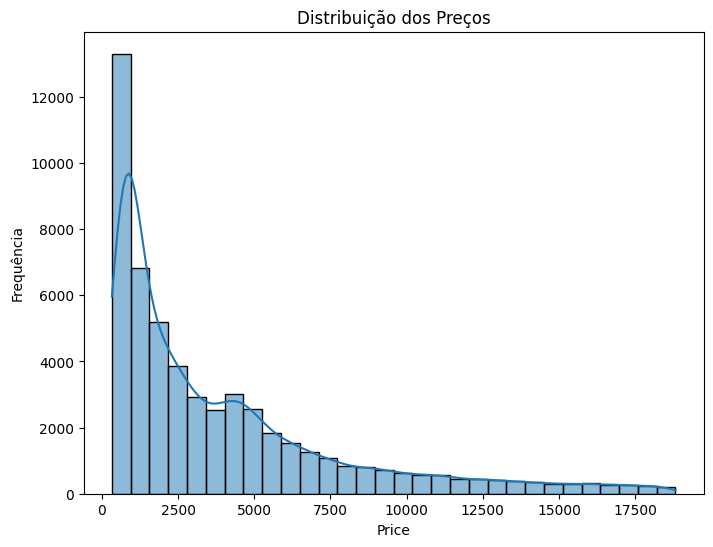

In [8]:
plt.figure(figsize=(8, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribuição dos Preços')
plt.xlabel('Price')
plt.ylabel('Frequência')
plt.show()


**Comentário:**  
  
A distribuição de `price` é fortemente enviesada à direita (long tail).  
Recomenda-se analisar `log1p(price)` para estabilizar variância e melhorar ajuste de modelos lineares

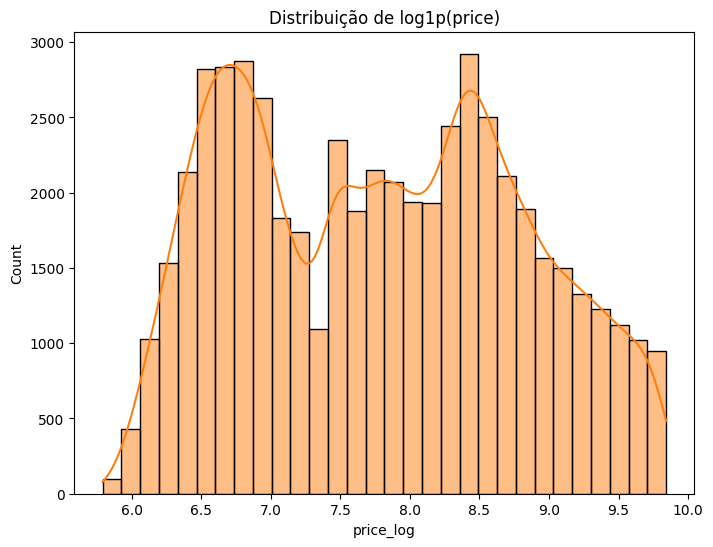

In [9]:
# Transformação do target
_df = df.copy()
_df['price_log'] = np.log1p(_df['price'])
plt.figure(figsize=(8,6))
sns.histplot(_df['price_log'], bins=30, kde=True, color='C1')
plt.title('Distribuição de log1p(price)')
plt.show()

## Análise das variáveis

### carat
- Peso do diamante  

#### tipo de dado

In [10]:
print(df['carat'].dtype)

float64


#### valores unicos

In [11]:
print(df['carat'].nunique())


273


#### distribuição

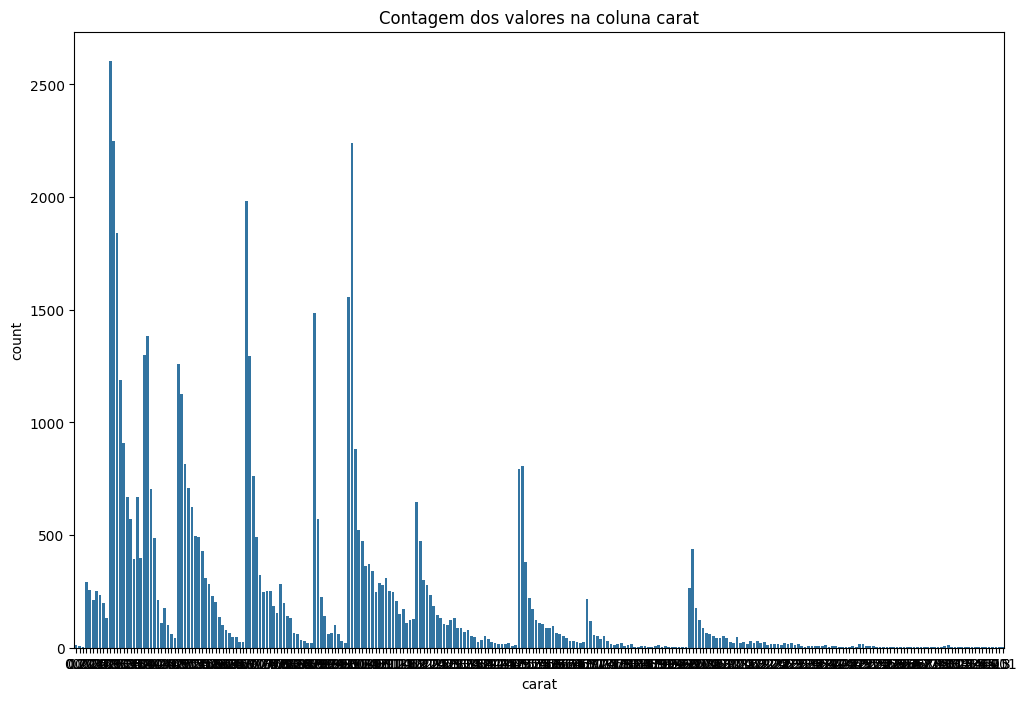

In [12]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='carat')
plt.title('Contagem dos valores na coluna carat')
plt.show()


#### histograma

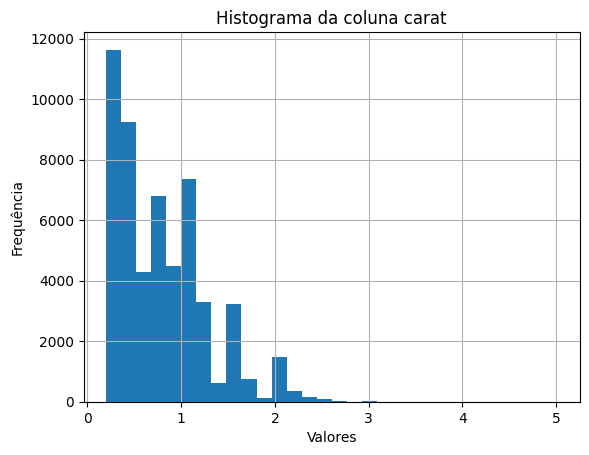

In [13]:
df['carat'].hist(bins=30)
plt.title('Histograma da coluna carat')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### boxplot

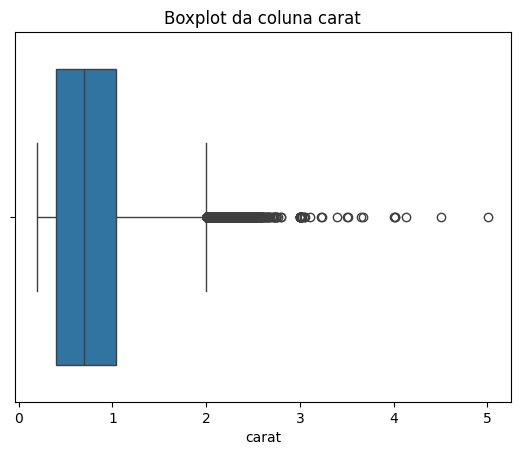

In [14]:
sns.boxplot(data=df, x='carat')
plt.title('Boxplot da coluna carat')
plt.show()

**Comentário:**  
`carat` possui distribuição assimétrica com alguns outliers.  
Recomenda-se criar `carat_log = log1p(carat)` para modelagem linear e `carat_bin` para análises descritivas.

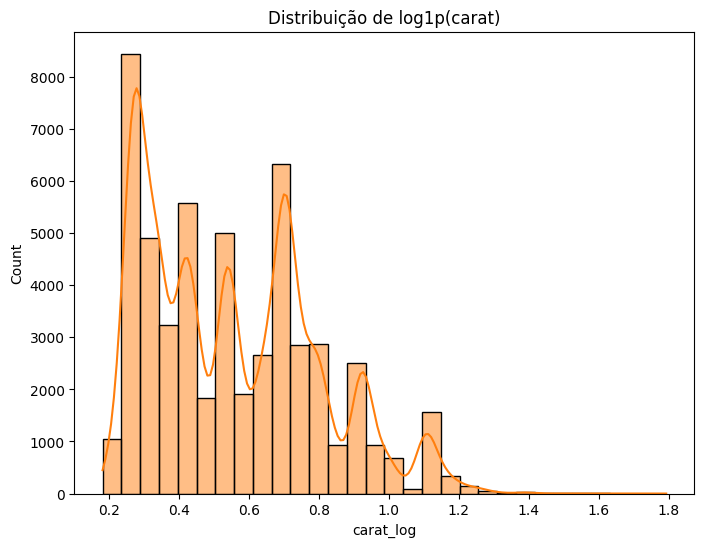

In [15]:
# Transformações em carat

df['carat_log'] = np.log1p(df['carat'])
plt.figure(figsize=(8,6))
sns.histplot(df['carat_log'], bins=30, kde=True, color='C1')
plt.title('Distribuição de log1p(carat)')
plt.show()

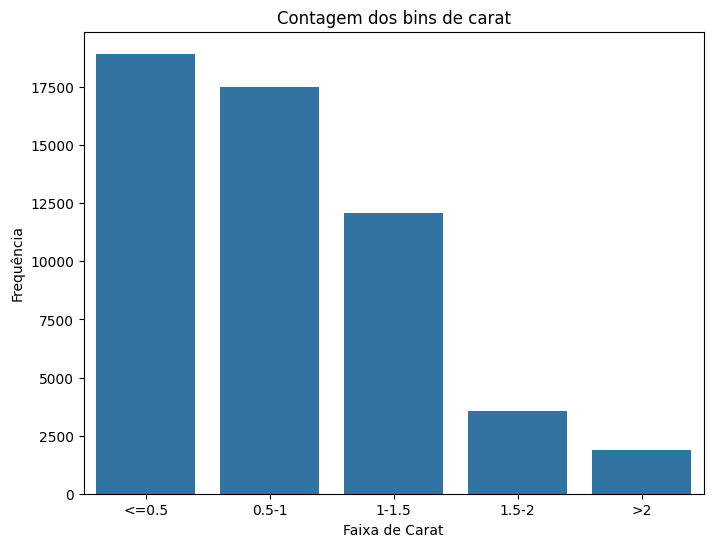

In [16]:
# exemplo de binning simples
df['carat_bin'] = pd.cut(df['carat'], bins=[0,0.5,1,1.5,2,10], labels=['<=0.5','0.5-1','1-1.5','1.5-2','>2'])
df['carat_bin'].value_counts()
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='carat_bin', order=['<=0.5','0.5-1','1-1.5','1.5-2','>2'])
plt.title('Contagem dos bins de carat')
plt.xlabel('Faixa de Carat')
plt.ylabel('Frequência')
plt.show()

### cut

- Qualidade do corte do diamante (Fair, Good, Very Good, Premium, Ideal).

#### tipo de dado

In [17]:
print(df['cut'].dtype)

category


#### valores unicos

In [18]:
print(df['cut'].nunique())


5


#### distribuição

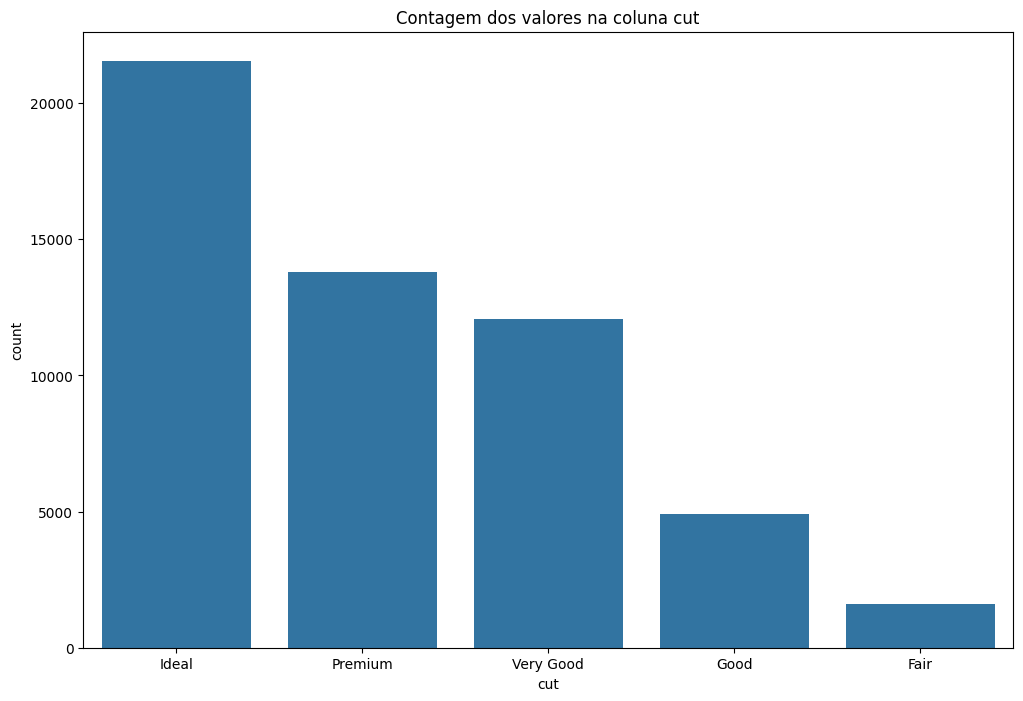

In [19]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='cut')
plt.title('Contagem dos valores na coluna cut')
plt.show()


#### histograma

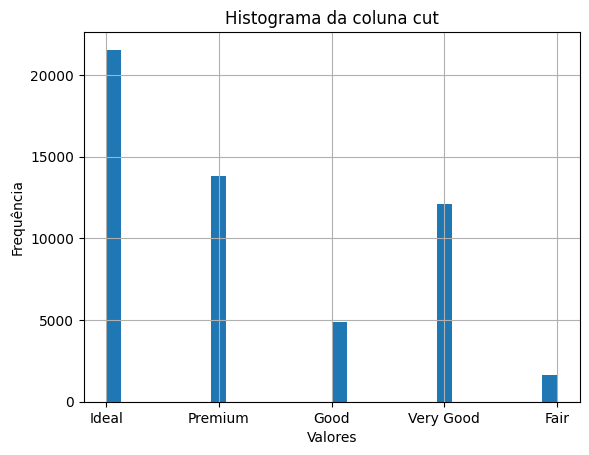

In [20]:
df['cut'].hist(bins=30)
plt.title('Histograma da coluna cut')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### PIZZA

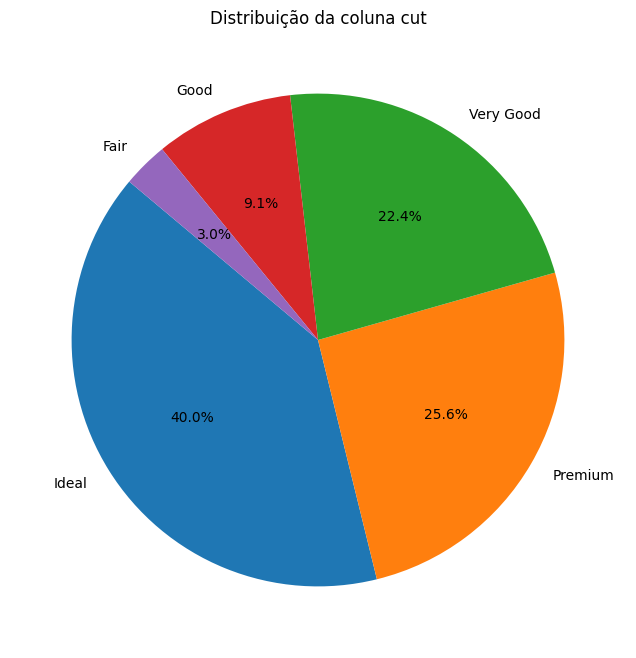

In [21]:
conta = df['cut'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(conta, labels=conta.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição da coluna cut')
plt.show()


### color

- Cor do diamante, de J (menos valioso) a D (mais valioso).


#### tipo de dado

In [22]:
print(df['color'].dtype)

category


#### valores unicos

In [23]:
print(df['color'].nunique())


7


#### distribuição

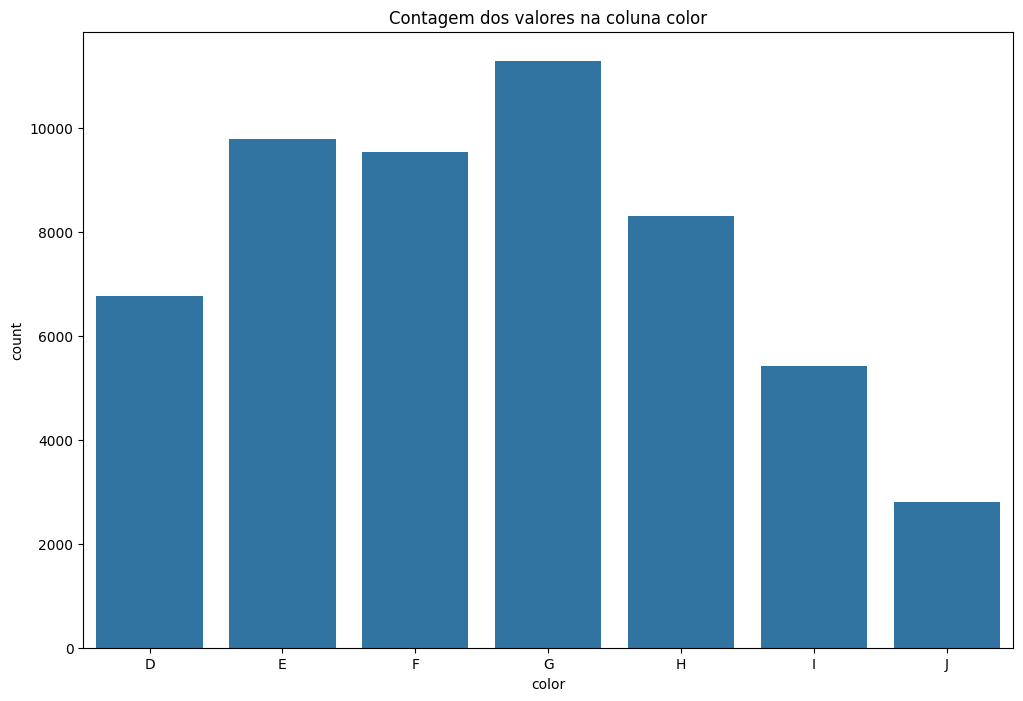

In [24]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='color')
plt.title('Contagem dos valores na coluna color')
plt.show()


#### histograma

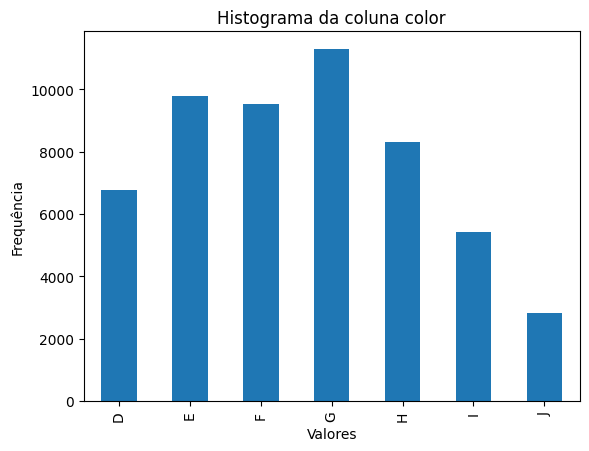

In [25]:
df['color'].value_counts().sort_index().plot(kind='bar')
#df['color'].hist(bins=30)
plt.title('Histograma da coluna color')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

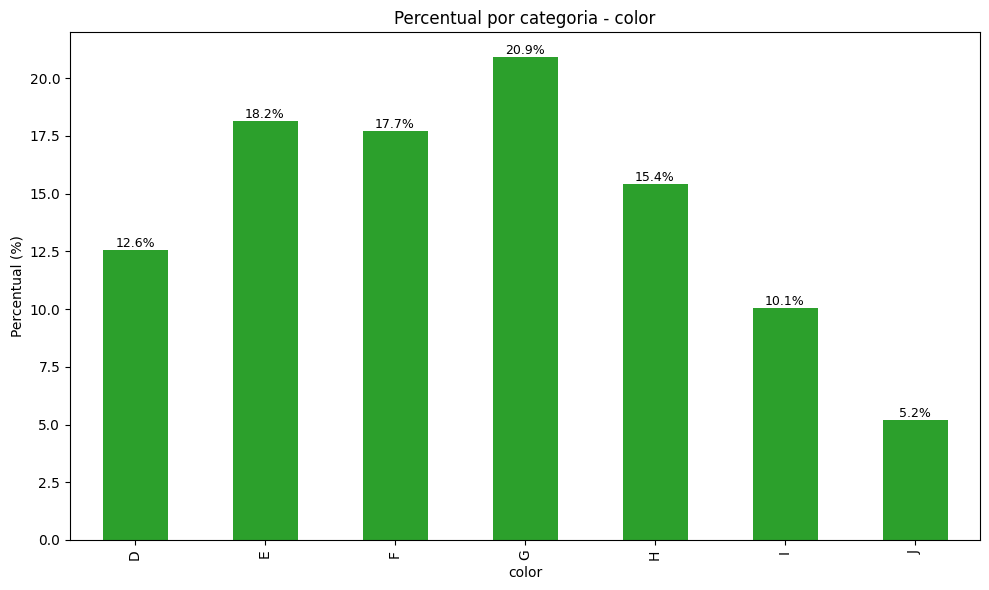

In [26]:
# Gráfico em percentual por categoria (ordenado)
counts = df['color'].value_counts().sort_index()
percent = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(10, 6))
percent.plot(kind='bar', color='C2', ax=ax)
ax.set_title('Percentual por categoria - color')
ax.set_xlabel('color')
ax.set_ylabel('Percentual (%)')
# Anotar valores percentuais acima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### PIZZA

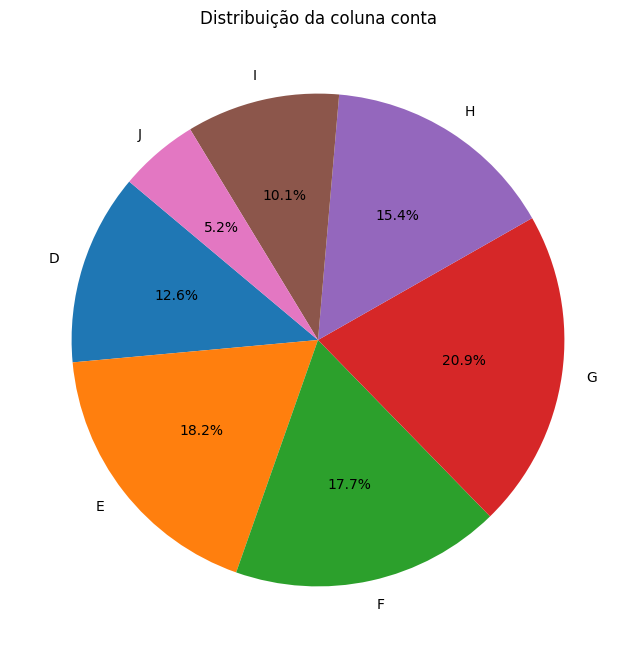

In [27]:
conta = df['color'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
plt.pie(conta, labels=conta.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição da coluna conta')
plt.show()


### clarity

- Claridade do diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF).  


#### tipo de dado

In [28]:
print(df['clarity'].dtype)

category


#### valores unicos

In [29]:
print(df['clarity'].nunique())


8


#### distribuição

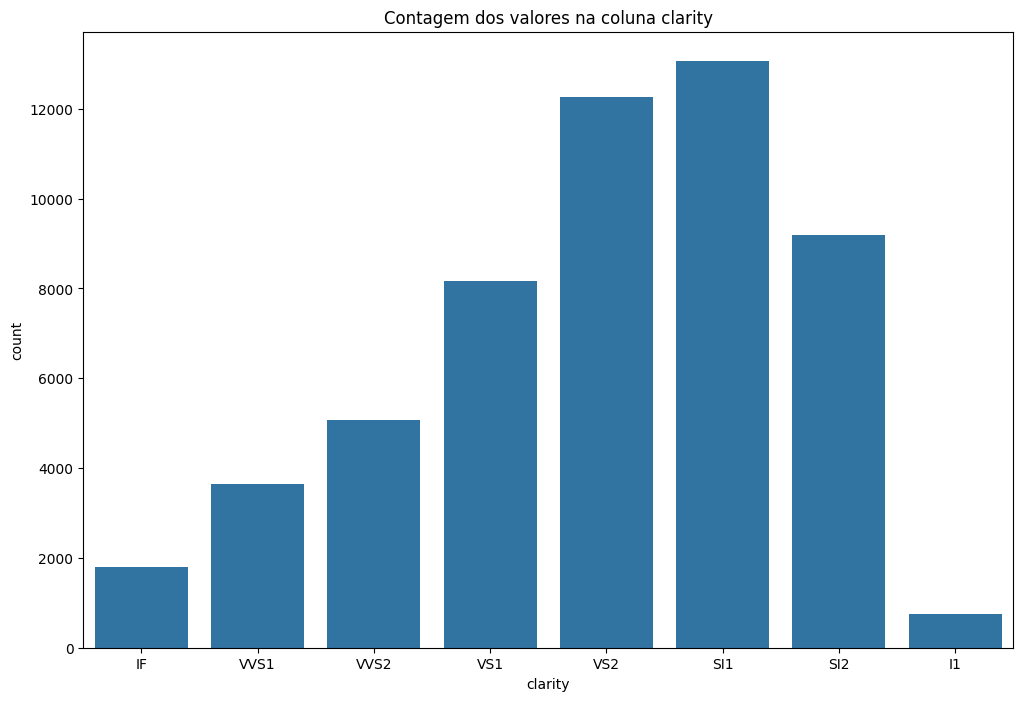

In [30]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='clarity')
plt.title('Contagem dos valores na coluna clarity')
plt.show()


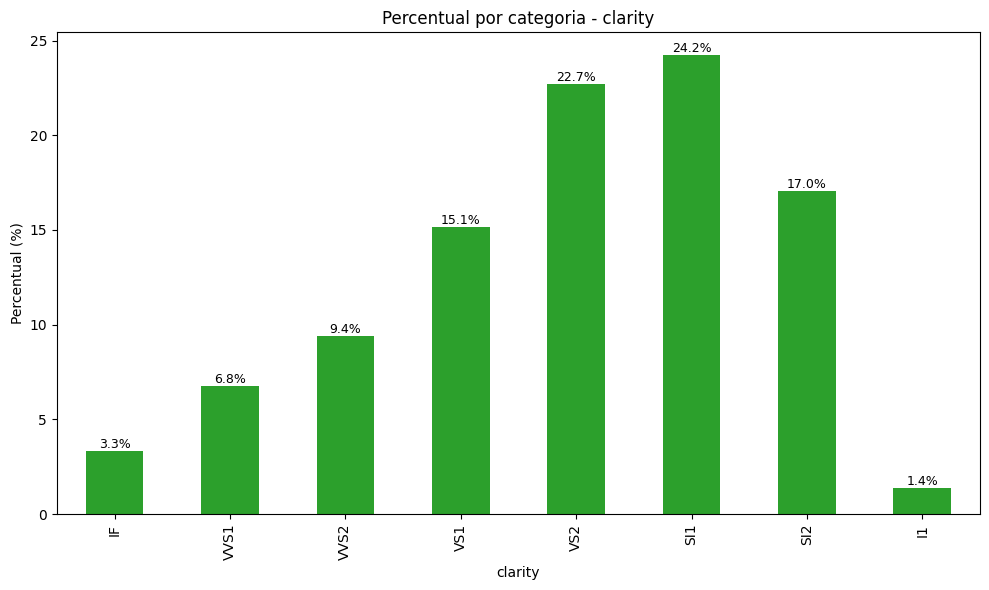

In [31]:
# Gráfico em percentual por categoria (ordenado)
counts = df['clarity'].value_counts().sort_index()
percent = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(10, 6))
percent.plot(kind='bar', color='C2', ax=ax)
ax.set_title('Percentual por categoria - clarity')
ax.set_xlabel('clarity')
ax.set_ylabel('Percentual (%)')
# Anotar valores percentuais acima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### PIZZA

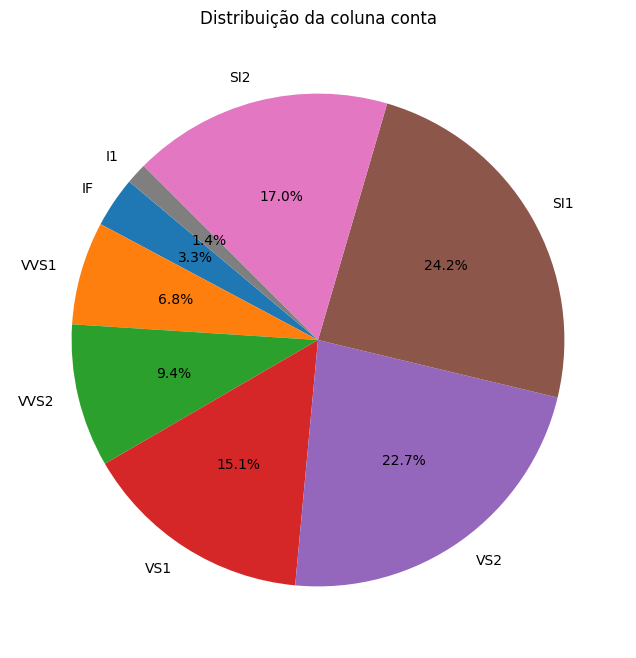

In [32]:
conta = df['clarity'].value_counts().sort_index()
plt.figure(figsize=(8, 8))
plt.pie(conta, labels=conta.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição da coluna conta')
plt.show()


### depth

- Profundidade total do diamante como uma porcentagem da média do diâmetro.  


#### tipo de dado

In [33]:
print(df['depth'].dtype)

float64


#### valores unicos

In [34]:
print(df['depth'].nunique())


184


#### distribuição

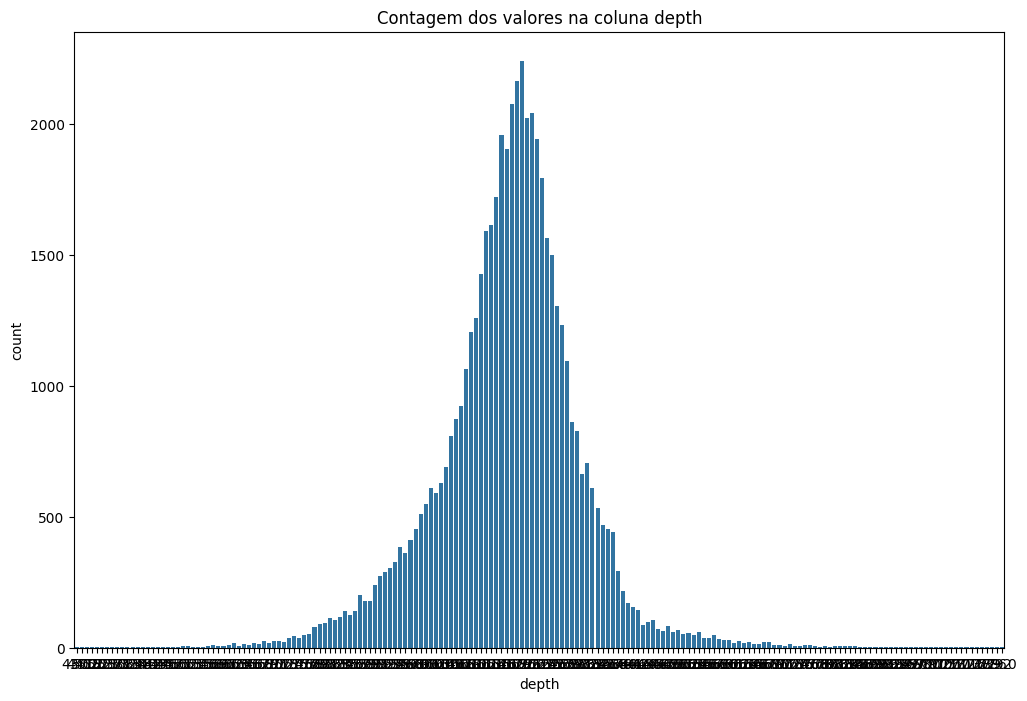

In [35]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='depth')
plt.title('Contagem dos valores na coluna depth')
plt.show()


#### histograma

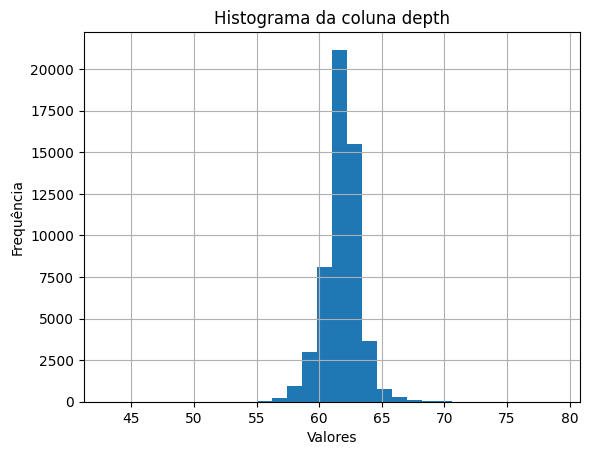

In [36]:
df['depth'].hist(bins=30)
plt.title('Histograma da coluna depth')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### boxplot

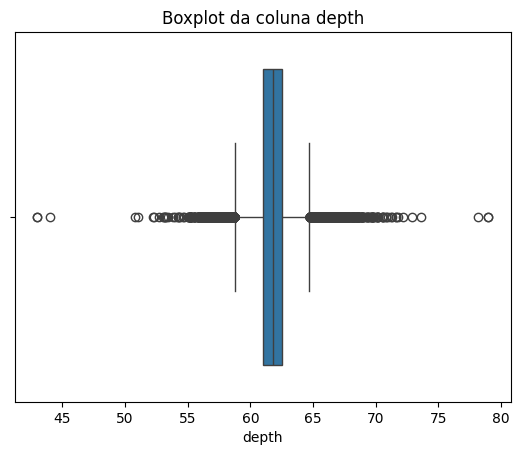

In [37]:
sns.boxplot(data=df, x='depth')
plt.title('Boxplot da coluna depth')
plt.show()

### table

- Largura da mesa do diamante como uma porcentagem da média do diâmetro.  

#### tipo de dado

In [38]:
print(df['table'].dtype)

float64


#### valores unicos

In [39]:
print(df['table'].nunique())


127


#### distribuição

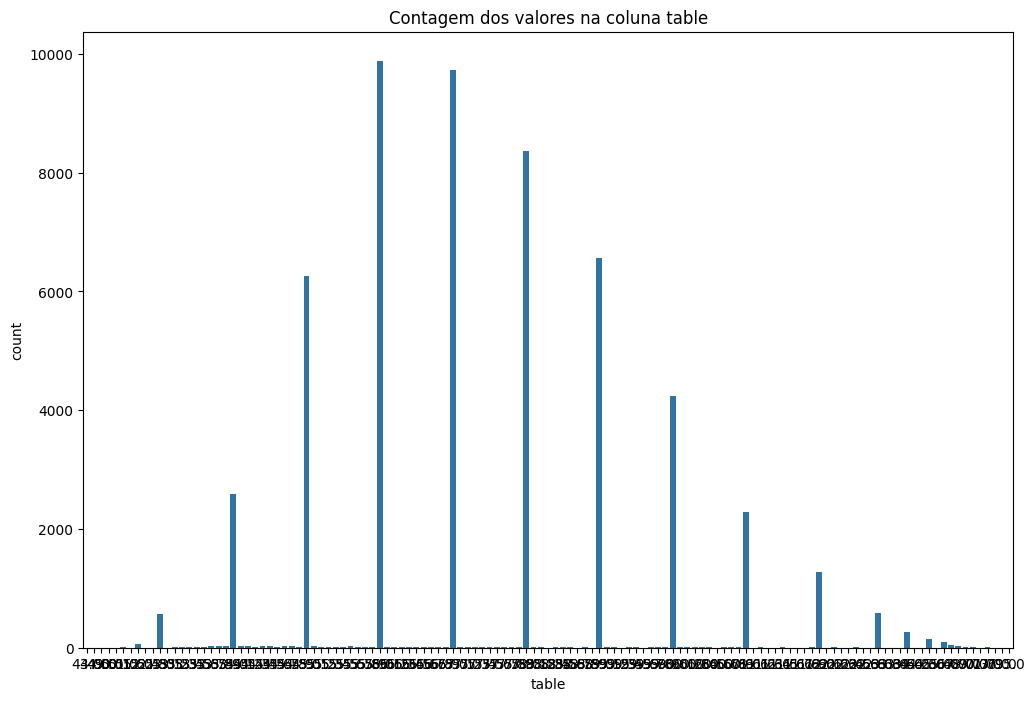

In [40]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='table')
plt.title('Contagem dos valores na coluna table')
plt.show()


#### histograma

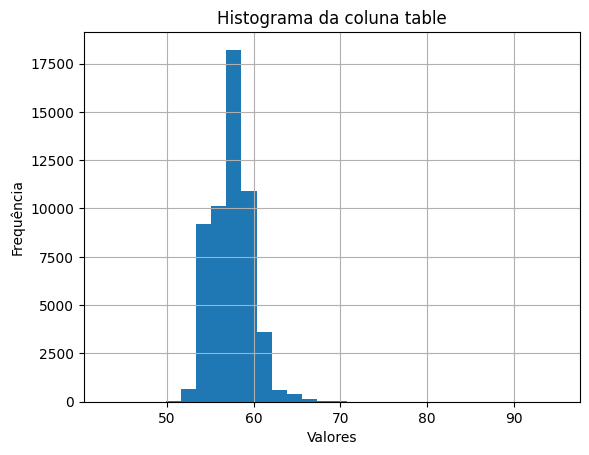

In [41]:
df['table'].hist(bins=30)
plt.title('Histograma da coluna table')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### boxplot

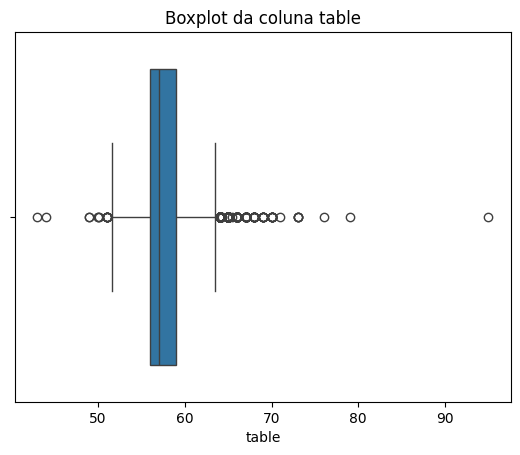

In [42]:
sns.boxplot(data=df, x='table')
plt.title('Boxplot da coluna table')
plt.show()

### x

- Comprimento em milímetros.  


#### tipo de dado

In [43]:
print(df['x'].dtype)

float64


#### valores unicos

In [44]:
print(df['x'].nunique())


554


#### distribuição

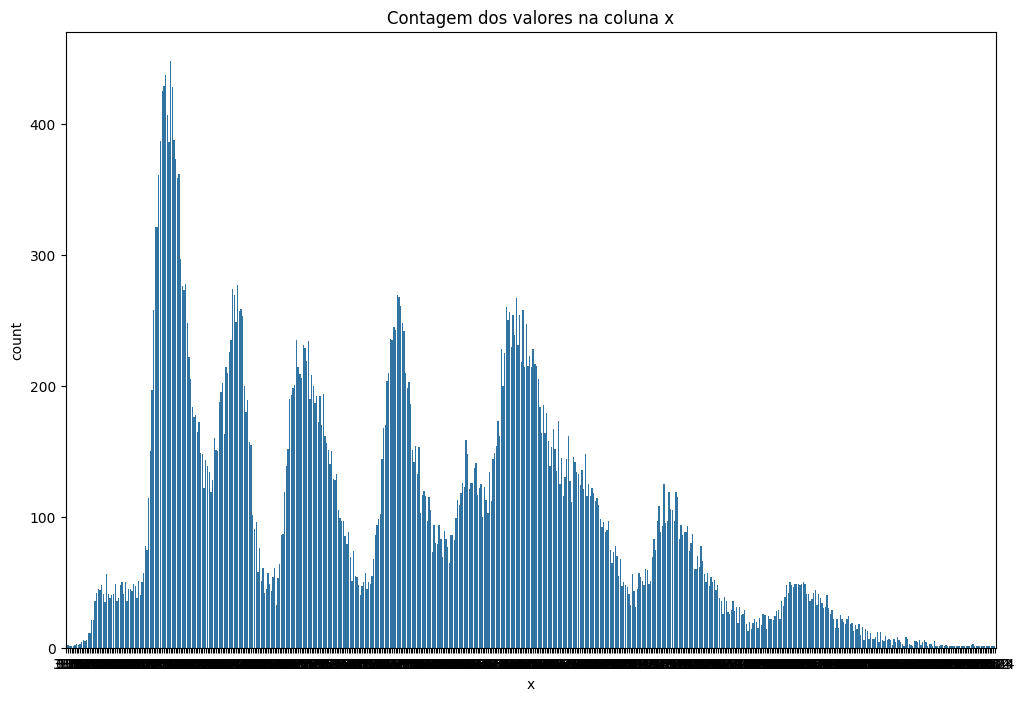

In [45]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='x')
plt.title('Contagem dos valores na coluna x')
plt.show()


#### histograma

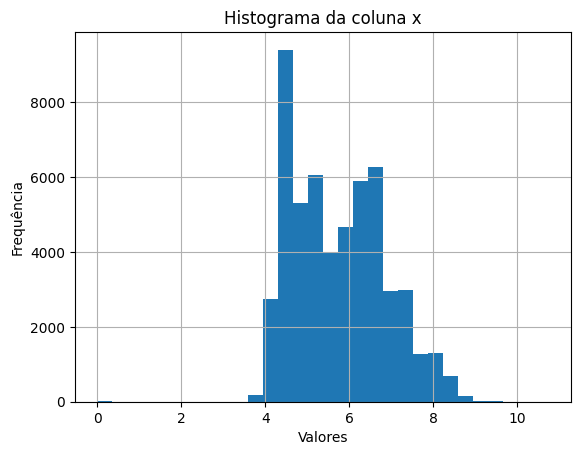

In [46]:
df['x'].hist(bins=30)
plt.title('Histograma da coluna x')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### boxplot

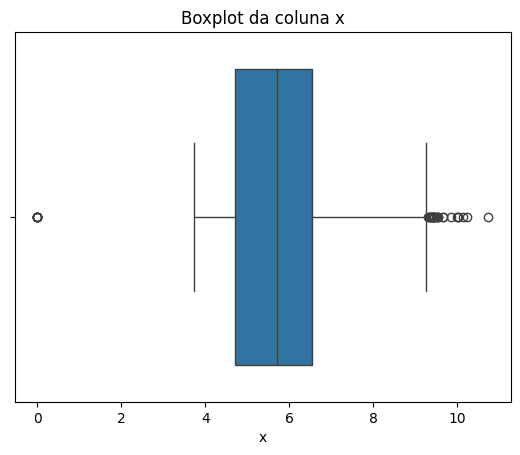

In [47]:
sns.boxplot(data=df, x='x')
plt.title('Boxplot da coluna x')
plt.show()

### y

- Largura em milímetros.  


#### tipo de dado

In [48]:
print(df['y'].dtype)

float64


#### valores unicos

In [49]:
print(df['y'].nunique())


552


#### distribuição

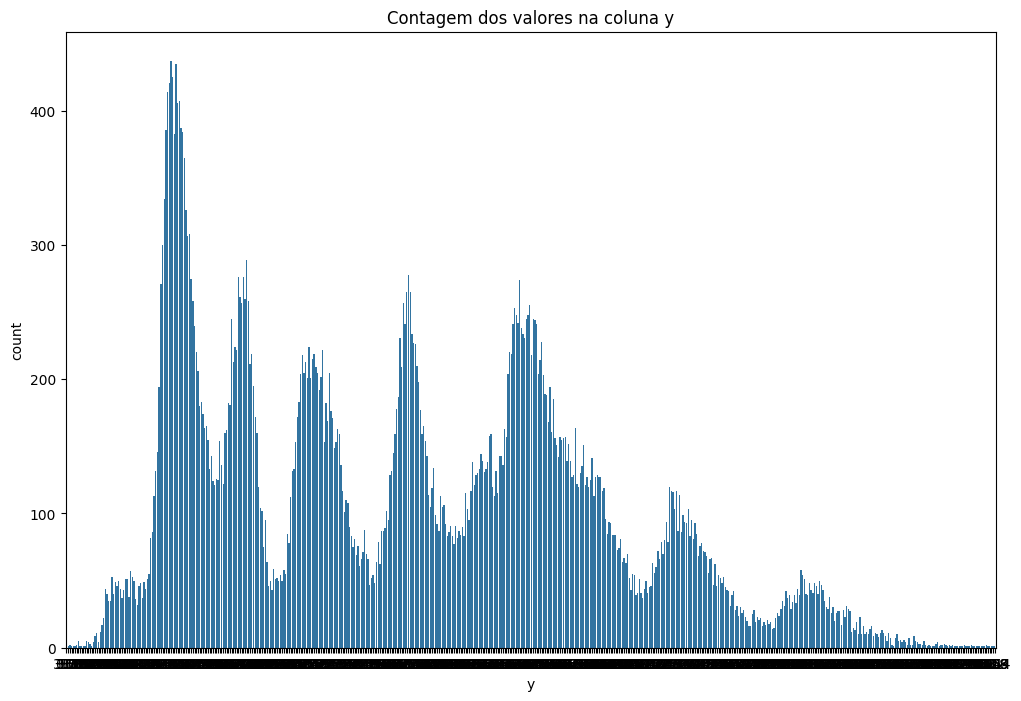

In [50]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='y')
plt.title('Contagem dos valores na coluna y')
plt.show()


#### histograma

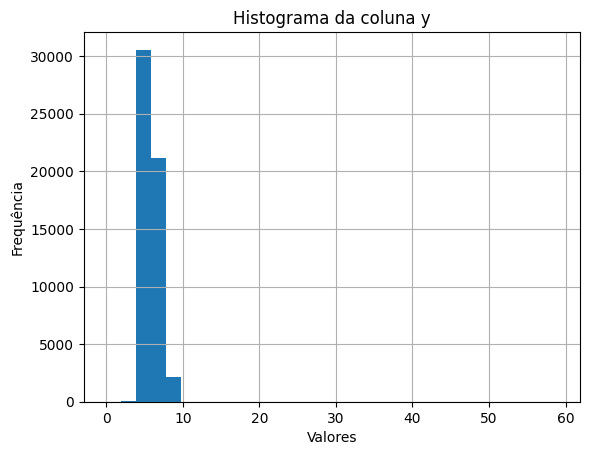

In [51]:
df['y'].hist(bins=30)
plt.title('Histograma da coluna y')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### boxplot

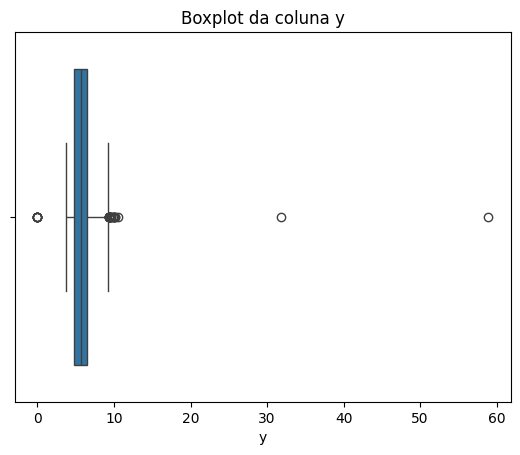

In [52]:
sns.boxplot(data=df, x='y')
plt.title('Boxplot da coluna y')
plt.show()

### z

- Profundidade em milímetros.


#### tipo de dado

In [53]:
print(df['z'].dtype)

float64


#### valores unicos

In [54]:
print(df['z'].nunique())


375


#### distribuição

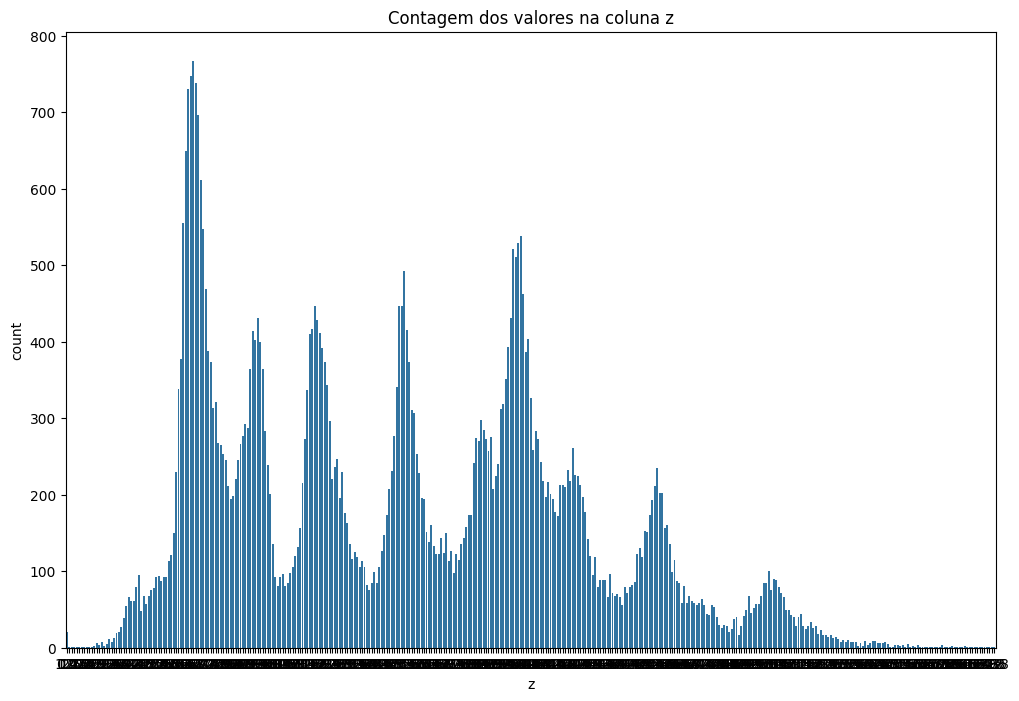

In [55]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='z')
plt.title('Contagem dos valores na coluna z')
plt.show()


#### histograma

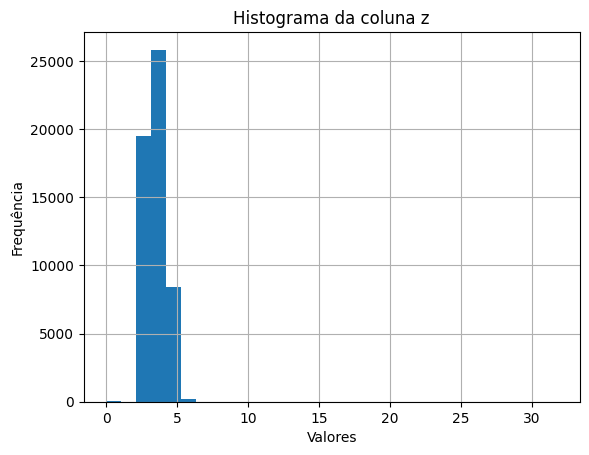

In [56]:
df['z'].hist(bins=30)
plt.title('Histograma da coluna z')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

#### boxplot

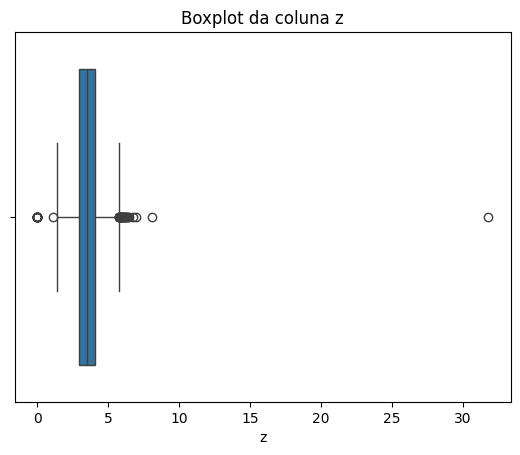

In [57]:
sns.boxplot(data=df, x='z')
plt.title('Boxplot da coluna z')
plt.show()

**Comentário:** 

- verificar e remover linhas com dimensões zero (x==0 | y==0 | z==0)
- criar `volume = x*y*z` e analisar correlação com `price`. 
- Se houver muitas linhas inválidas documentar a origem.

## Feature Engeniering

### Volume

In [58]:
# Limpeza e feature derivada: volume
invalid = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)
print('Linhas com dimensões inválidas:', invalid.sum())
df = df[~invalid].copy()
df['volume'] = df['x'] * df['y'] * df['z']

Linhas com dimensões inválidas: 20


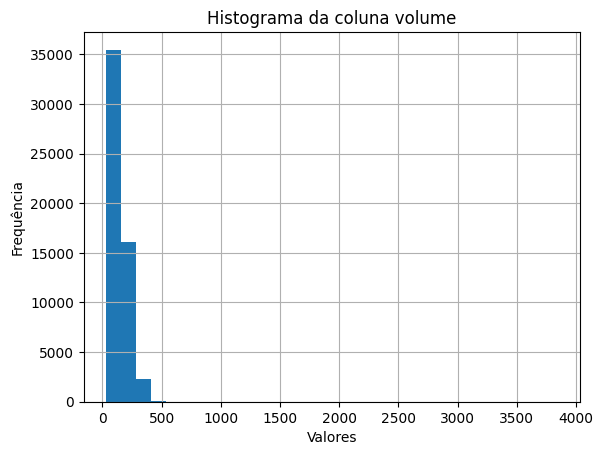

In [59]:
df['volume'].hist(bins=30)
plt.title('Histograma da coluna volume')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

### volume_log

In [60]:
df['volume_log'] = np.log1p(df['volume'])
print('Exemplo: correlação volume vs price:', df[['volume','price']].corr().iloc[0,1])

Exemplo: correlação volume vs price: 0.9042546534713992


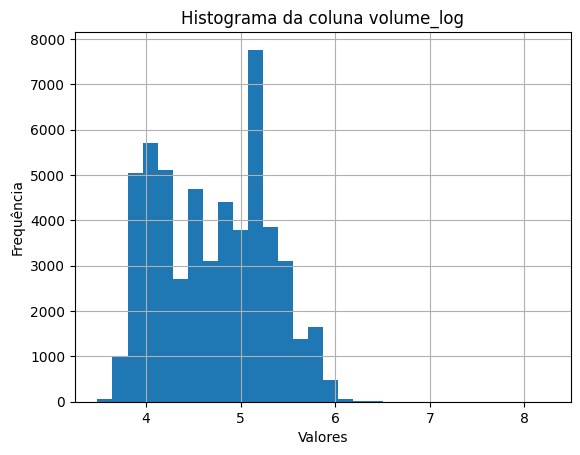

In [61]:
df['volume_log'].hist(bins=30)
plt.title('Histograma da coluna volume_log')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

## Matriz de correlação

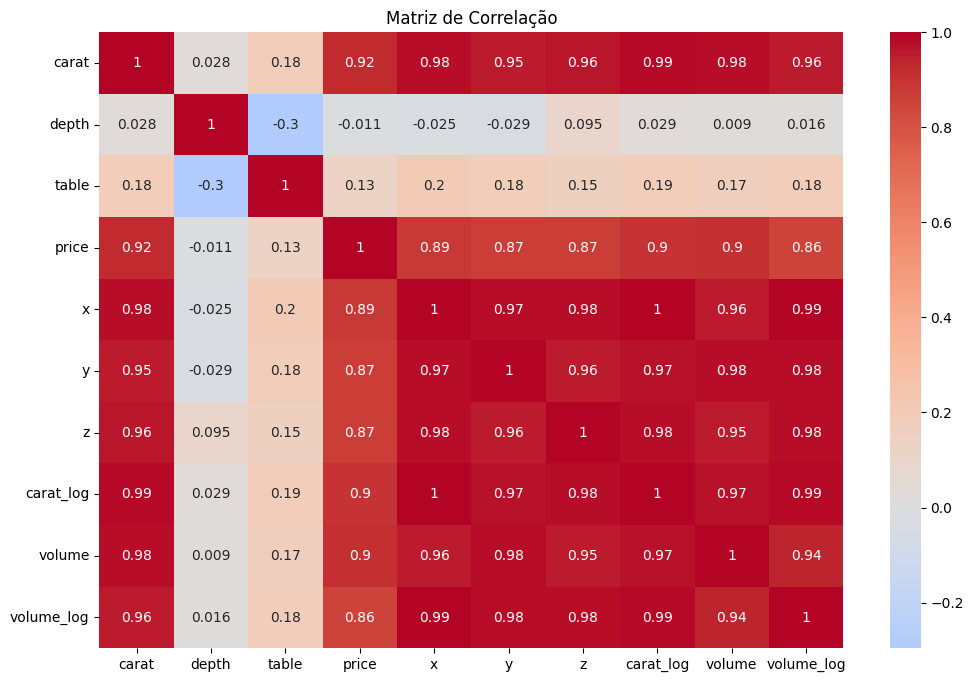

In [62]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

**Comentário:** 

- calcular VIF para detectar multicolinearidade entre variáveis numéricas (ex.: x,y,z).

## VIF

In [63]:
X = df[['carat','carat_log','depth','table','x','y','z','volume', 'volume_log']].dropna()
vif_data = pd.DataFrame({'feature': X.columns, 'vif': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
display(vif_data)


,feature,vif
0,carat,1377.198732
1,carat_log,2216.002249
2,depth,3440.830945
3,table,607.974233
4,x,24815.811179
5,y,9087.439357
6,z,2387.324882
7,volume,1296.211152
8,volume_log,71281.972361


C:\Users\André Ricardo\AppData\Local\Temp\ipykernel_19608\1720693427.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_plot, x='feature', y='vif', palette='viridis')


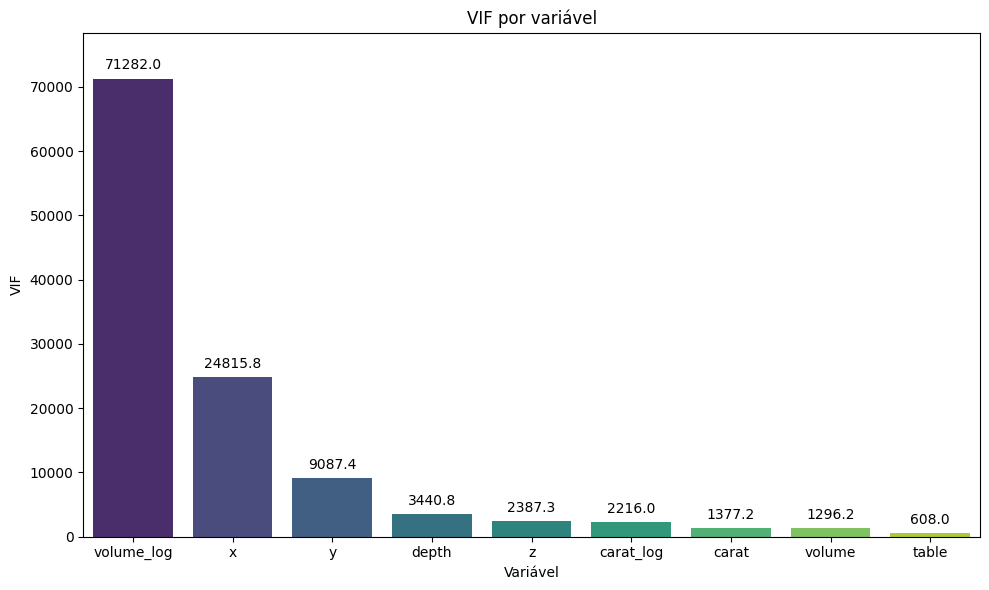

In [64]:
vif_plot = vif_data.sort_values('vif', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=vif_plot, x='feature', y='vif', palette='viridis')
plt.title('VIF por variável')
plt.xlabel('Variável')
plt.ylabel('VIF')
plt.ylim(0, vif_plot['vif'].max() * 1.1)

for i, v in enumerate(vif_plot['vif']):
    plt.text(i, v + vif_plot['vif'].max() * 0.02, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

Analise

O resultado mostra multicolinearidade muito alta entre as variáveis:

- VIF > 10 já indica problema sério; aqui todos os valores estão muito acima disso.
- `x`, `y` e `z` têm VIF extremamente altos, o que é esperado porque são medidas de dimensão muito correlacionadas.
- `volume` também apresenta VIF alto, pois é derivado de `x * y * z` e, portanto, é redundante em relação a essas variáveis.
- `carat` tem VIF elevado porque está fortemente correlacionado com as dimensões do diamante.
- `depth` e `table` também têm VIF alto, indicando que há multicolinearidade mesmo entre variáveis independentes.

Conclusão:
- o modelo linear com essas variáveis terá instabilidade nos coeficientes;
- é recomendável remover ou agrupar variáveis redundantes (por exemplo, manter só `carat` ou só `volume`/`x,y,z`);
- outra alternativa é usar regularização ou redução de dimensionalidade.

## Scatter plots entre features numéricas + target

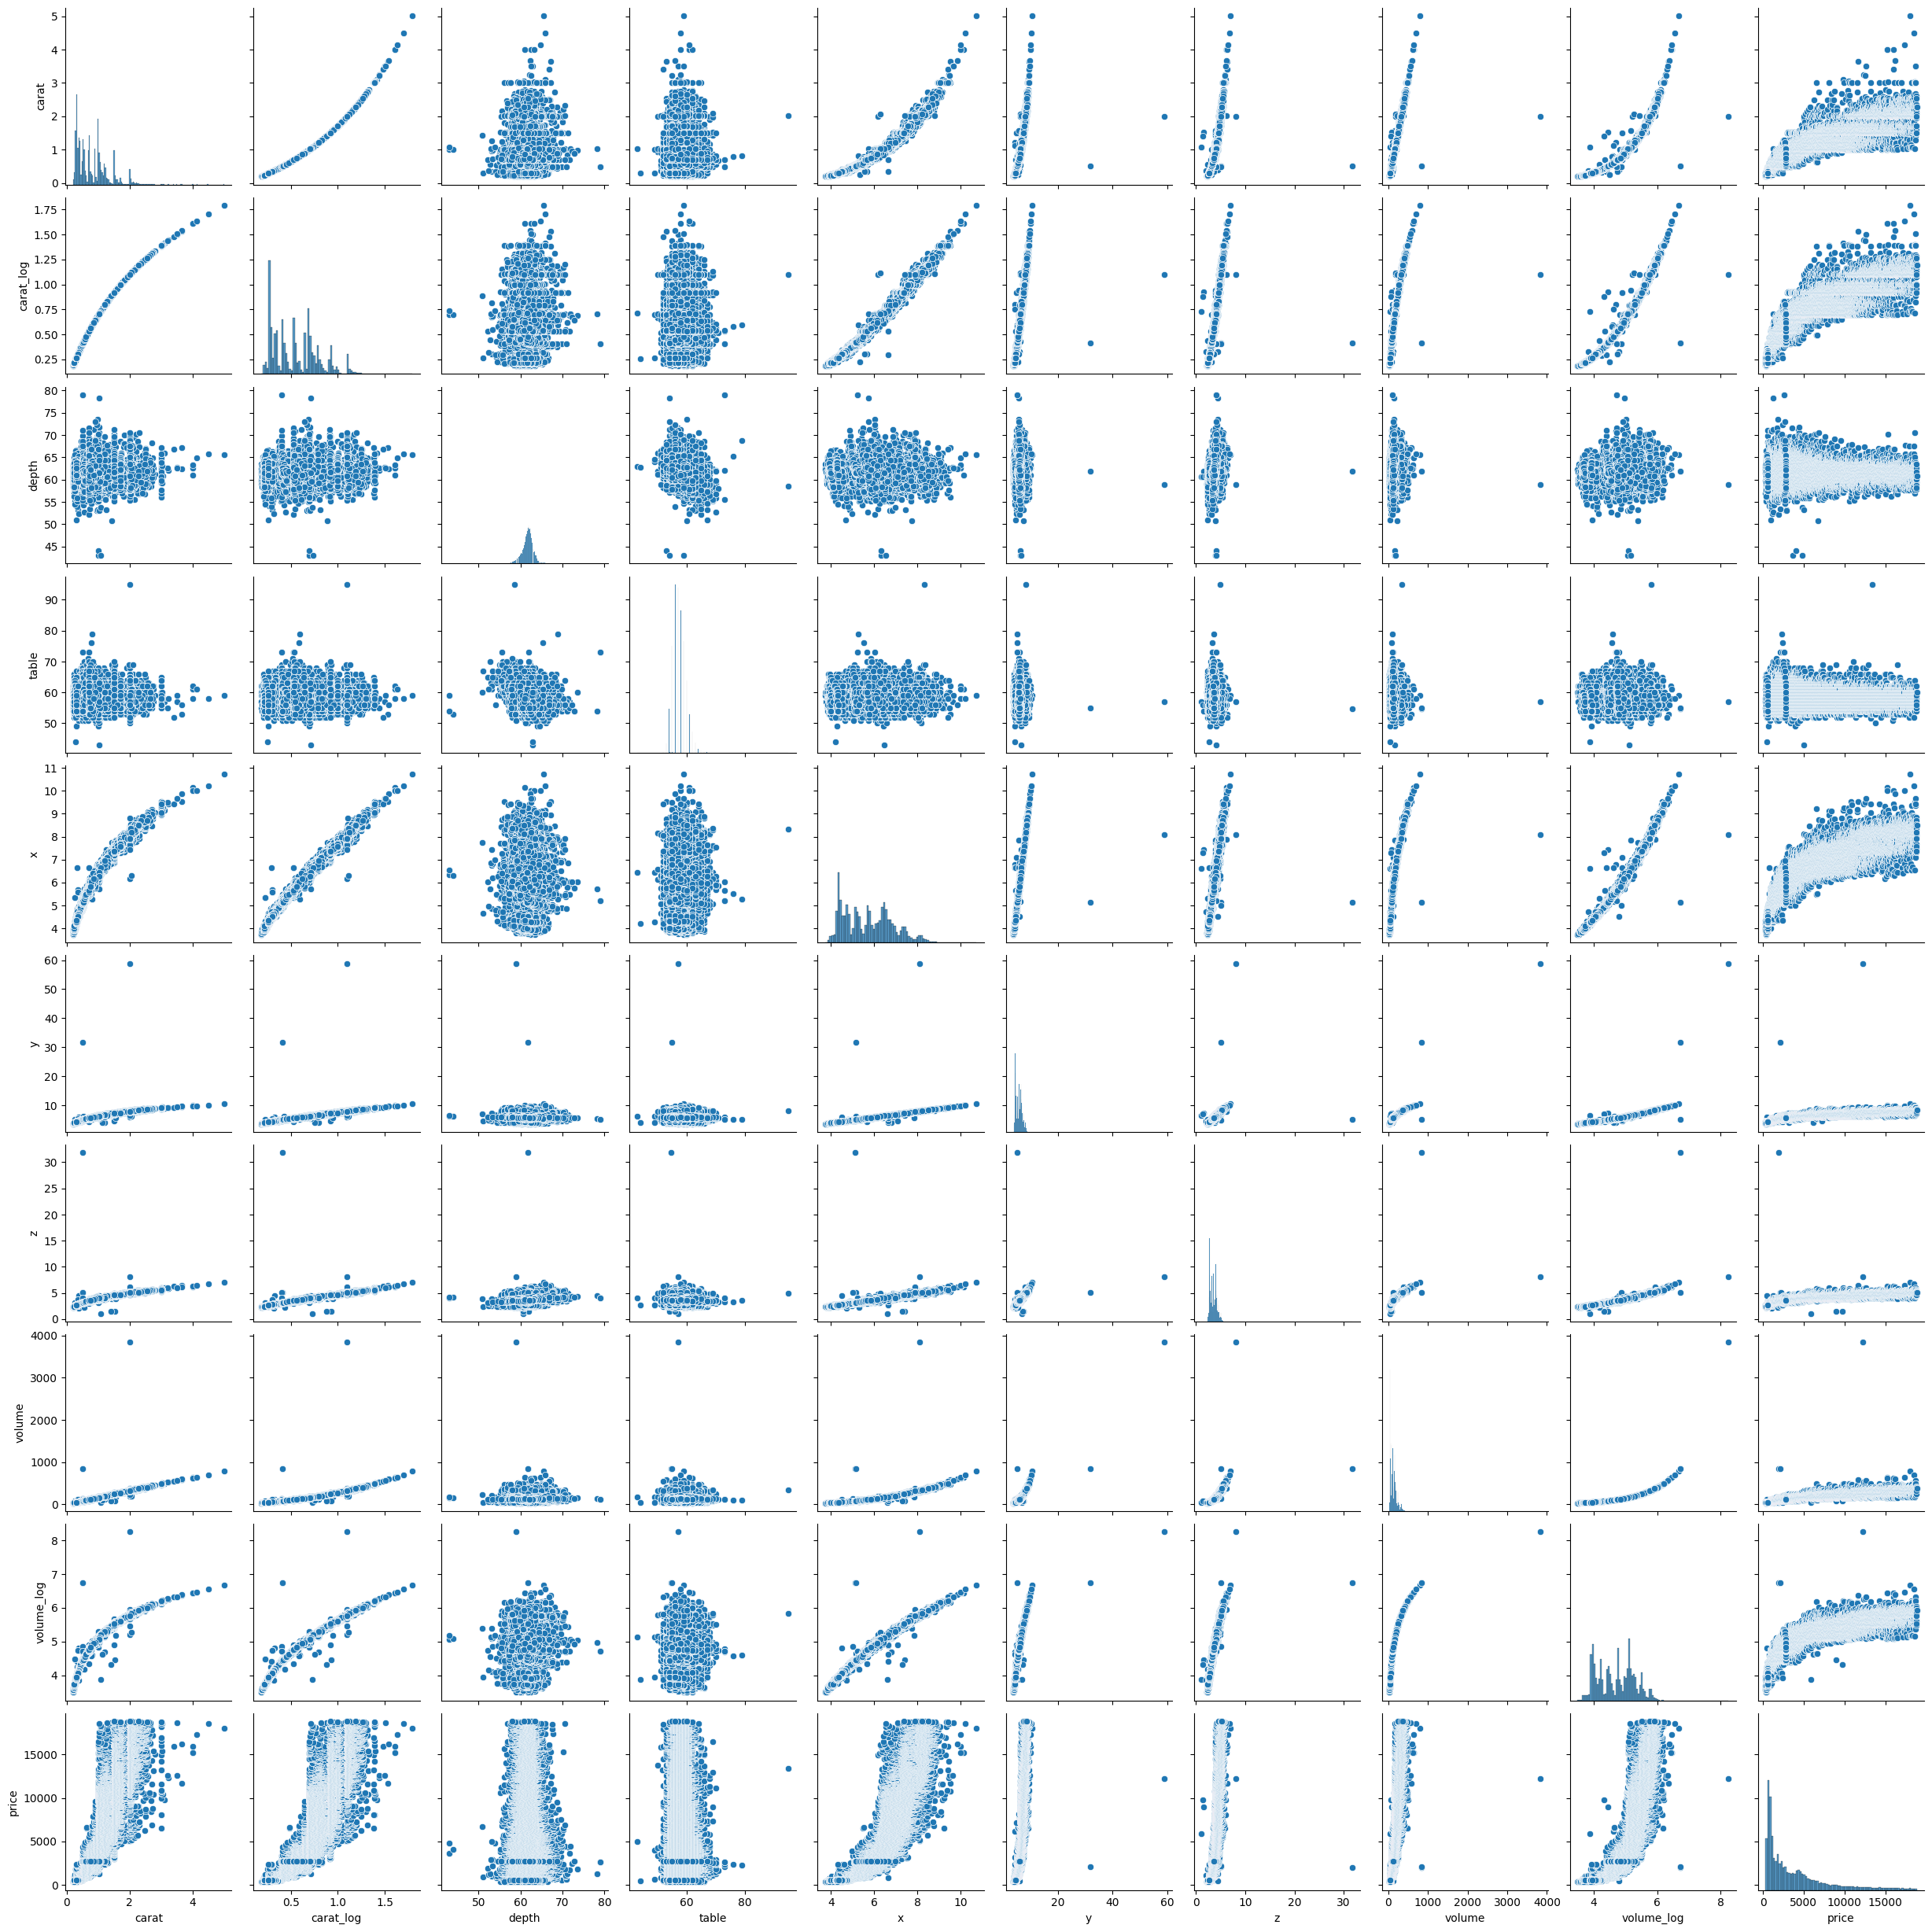

In [65]:
colunas = ['carat', 'carat_log', 'depth', 'table', 'x', 'y', 'z', 'volume', 'volume_log', 'price']
sns.pairplot(df[colunas])
plt.show()

# Relatório automático (ydata-profiling)

In [66]:
profile = ProfileReport(df, title='Diamonds profile', explorative=True)
profile.to_file('diamonds_profile.html')
print('Relatório salvo em diamonds_profile.html')


Export report to file: 100%|██████████| 1/1 [00:00<00:00,  6.98it/s]

Relatório salvo em diamonds_profile.html
